# Titanic Data Workflow

**Author:** Johannes Pawelczyk  
**Dataset:** [Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic/data)

This notebook presents a reproducible exploratory workflow for the Titanic
passenger training dataset. It audits and cleans the data, summarizes relevant
passenger groups, produces three labeled visualizations, and interprets the
patterns without training a machine-learning model or making causal claims.

## 1. Setup

Import the required libraries, configure a consistent plotting style, and define
relative project paths. A fixed seed is included so any future sampling added to
the workflow remains reproducible.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("data/titanic.csv")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

## 2. Data Ingestion

Load the CSV with Pandas, display the first rows, and verify its dimensions and
column types before changing anything.

In [2]:
raw_df = pd.read_csv(DATA_PATH)
print(f"Raw shape: {raw_df.shape[0]} rows x {raw_df.shape[1]} columns")
raw_df.head()

Raw shape: 891 rows x 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
ingestion_audit = pd.DataFrame(
    {
        "dtype": raw_df.dtypes.astype(str),
        "missing_count": raw_df.isna().sum(),
        "missing_percent": (raw_df.isna().mean() * 100).round(1),
        "unique_values": raw_df.nunique(dropna=True),
    }
)
ingestion_audit

,dtype,missing_count,missing_percent,unique_values
PassengerId,int64,0,0.0,891
Survived,int64,0,0.0,2
Pclass,int64,0,0.0,3
Name,str,0,0.0,891
Sex,str,0,0.0,2
Age,float64,177,19.9,88
SibSp,int64,0,0.0,7
Parch,int64,0,0.0,7
Ticket,str,0,0.0,681
Fare,float64,0,0.0,248


The source contains **891 rows and 12 columns**. Age has 177 missing values,
Cabin has 687, and Embarked has 2. The cleaning workflow therefore preserves
missingness information rather than deleting every incomplete passenger.

## 3. Data Cleaning

Two reusable functions are defined and applied below. Column normalization makes
names predictable. Dataset-specific cleaning then removes exact duplicates,
handles missing values, preserves missingness indicators, and creates a small set
of transparent features used in the exploratory analysis.

In [4]:
def normalize_column_names(data: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with stripped, lowercase, snake_case column names."""
    normalized = data.copy()
    normalized.columns = (
        normalized.columns.str.strip()
        .str.replace(r"[^0-9A-Za-z]+", "_", regex=True)
        .str.strip("_")
        .str.lower()
    )
    return normalized


def clean_titanic_data(data: pd.DataFrame) -> pd.DataFrame:
    """Clean Titanic records while preserving signals about missing data.

    Exact duplicates are removed. Missing age is imputed with the median for the
    passenger's sex/class group and tracked in ``age_missing``. The two missing
    embarkation ports use the modal port. Raw cabin strings are replaced by a
    ``cabin_known`` indicator because 77% are missing. Family-size features are
    derived from the documented sibling/spouse and parent/child counts.
    """
    cleaned = data.copy().drop_duplicates().reset_index(drop=True)

    for column in ["name", "sex", "ticket", "cabin", "embarked"]:
        cleaned[column] = cleaned[column].astype("string").str.strip()

    cleaned["age_missing"] = cleaned["age"].isna()
    grouped_age_median = cleaned.groupby(["sex", "pclass"])["age"].transform(
        "median"
    )
    cleaned["age"] = (
        cleaned["age"].fillna(grouped_age_median).fillna(cleaned["age"].median())
    )

    cleaned["embarked"] = cleaned["embarked"].fillna(
        cleaned["embarked"].mode().iloc[0]
    )
    cleaned["cabin_known"] = cleaned["cabin"].notna()
    cleaned["family_size"] = cleaned["sibsp"] + cleaned["parch"] + 1
    cleaned["is_alone"] = cleaned["family_size"].eq(1)
    cleaned = cleaned.drop(columns=["cabin"])
    return cleaned

In [5]:
normalized_df = normalize_column_names(raw_df)
clean_df = clean_titanic_data(normalized_df)

cleaning_audit = pd.DataFrame(
    {
        "raw_missing": normalized_df.isna().sum(),
        "clean_missing": clean_df.isna().sum(),
    }
).fillna(0).astype(int)

print(f"Exact duplicate rows removed: {len(normalized_df) - len(clean_df)}")
print(f"Clean shape: {clean_df.shape[0]} rows x {clean_df.shape[1]} columns")
cleaning_audit.loc[
    cleaning_audit.sum(axis=1).gt(0) | cleaning_audit.index.isin(["age", "embarked"])
]

Exact duplicate rows removed: 0
Clean shape: 891 rows x 15 columns


,raw_missing,clean_missing
age,177,0
cabin,687,0
embarked,2,0


In [6]:
required_columns = {
    "survived", "pclass", "sex", "age", "fare", "embarked",
    "age_missing", "cabin_known", "family_size", "is_alone",
}
assert len(clean_df) == 891
assert required_columns.issubset(clean_df.columns)
assert clean_df[["age", "embarked"]].isna().sum().sum() == 0
assert clean_df["survived"].isin([0, 1]).all()
assert clean_df["family_size"].ge(1).all()
print("All cleaning validation checks passed.")

All cleaning validation checks passed.


**Cleaning justification.** Dropping all incomplete rows would remove nearly
four-fifths of the dataset because Cabin is sparse. Instead, the workflow avoids
inventing cabin labels and preserves only whether a cabin was recorded. Age is
imputed within sex and passenger class to retain observations while respecting
broad group structure; `age_missing` keeps the fact of imputation available for
later sensitivity analysis. These choices are assumptions, not recovered facts.

## 4. Exploratory Data Analysis

The function below returns group sizes, survivor counts, and survival rates. Group
counts are shown with rates so visually striking results from very small groups are
not mistaken for equally precise evidence.

In [7]:
def summarize_survival(
    data: pd.DataFrame, group_columns: str | list[str]
) -> pd.DataFrame:
    """Summarize passenger count, survivor count, and survival rate by group."""
    if isinstance(group_columns, str):
        group_columns = [group_columns]
    return (
        data.groupby(group_columns, dropna=False)["survived"]
        .agg(passengers="size", survivors="sum", survival_rate="mean")
        .assign(survival_rate=lambda frame: frame["survival_rate"].round(3))
        .reset_index()
    )


overall_survival_rate = clean_df["survived"].mean()
print(f"Overall survival rate: {overall_survival_rate:.1%}")
survival_by_class_and_sex = summarize_survival(clean_df, ["pclass", "sex"])
survival_by_class_and_sex

Overall survival rate: 38.4%


,pclass,sex,passengers,survivors,survival_rate
0,1,female,94,91,0.968
1,1,male,122,45,0.369
2,2,female,76,70,0.921
3,2,male,108,17,0.157
4,3,female,144,72,0.500
5,3,male,347,47,0.135


In [8]:
family_summary = summarize_survival(clean_df, "family_size")
family_summary

,family_size,passengers,survivors,survival_rate
0,1,537,163,0.304
1,2,161,89,0.553
2,3,102,59,0.578
3,4,29,21,0.724
4,5,15,3,0.200
5,6,22,3,0.136
6,7,12,4,0.333
7,8,6,0,0.000
8,11,7,0,0.000


The overall observed survival rate is 38.4%. Rates vary strongly by recorded sex
and passenger class: women have higher observed rates in every class, while first-
class passengers have higher rates than third-class passengers. Family-size rates
are non-linear, but groups above seven members contain fewer than ten passengers,
so those extreme percentages should be interpreted cautiously.

## 5. Visualizations

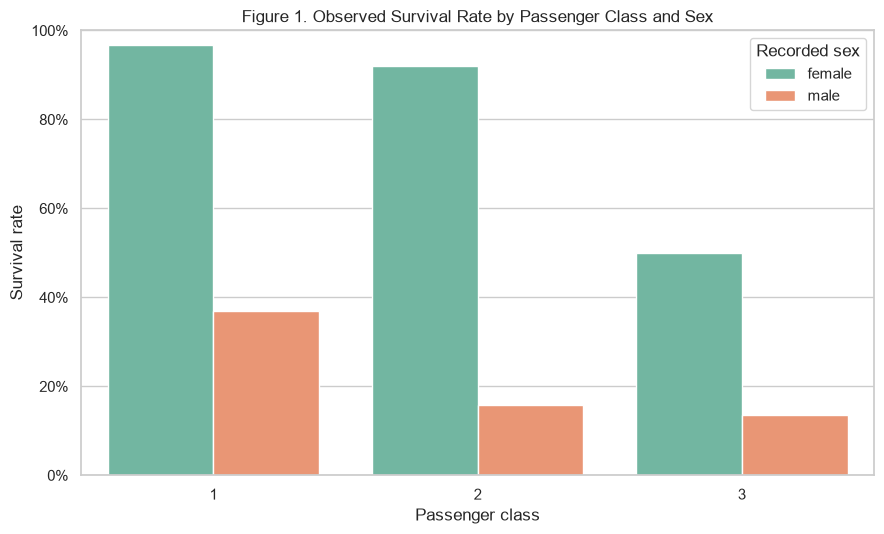

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=clean_df,
    x="pclass",
    y="survived",
    hue="sex",
    estimator="mean",
    errorbar=None,
    palette="Set2",
    ax=ax,
)
ax.set_title("Figure 1. Observed Survival Rate by Passenger Class and Sex")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.legend(title="Recorded sex")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "figure_1_survival_by_class_and_sex.png", dpi=180)
plt.show()

**Figure 1 interpretation.** Recorded women had higher observed survival in every
passenger class. First-class women had the highest rate (96.8%), while third-class
men had the lowest (13.5%). These are historical associations shaped by evacuation
practices and social structure, not causal effects or measures of individual merit.

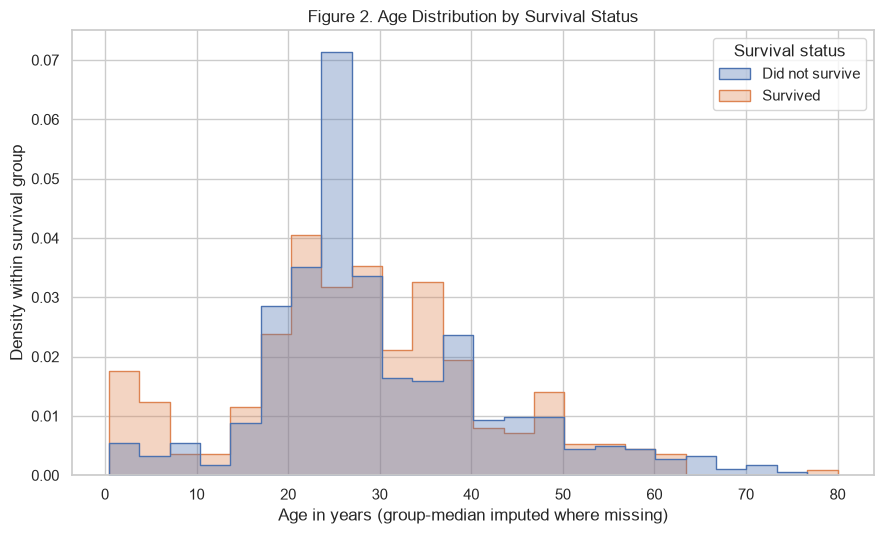

In [10]:
fig, ax = plt.subplots(figsize=(9, 5.5))
plot_df = clean_df.assign(
    survival_status=clean_df["survived"].map({0: "Did not survive", 1: "Survived"})
)
sns.histplot(
    data=plot_df,
    x="age",
    hue="survival_status",
    bins=24,
    stat="density",
    common_norm=False,
    element="step",
    alpha=0.35,
    ax=ax,
)
sns.move_legend(ax, "upper right", title="Survival status")
ax.set_title("Figure 2. Age Distribution by Survival Status")
ax.set_xlabel("Age in years (group-median imputed where missing)")
ax.set_ylabel("Density within survival group")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "figure_2_age_by_survival.png", dpi=180)
plt.show()

**Figure 2 interpretation.** The age distributions overlap substantially and both
groups have a median age of about 28 years before imputation. A visible child peak
among survivors warrants follow-up, but 177 ages were originally missing and the
plot uses imputed values, so fine-grained age differences should not be overstated.

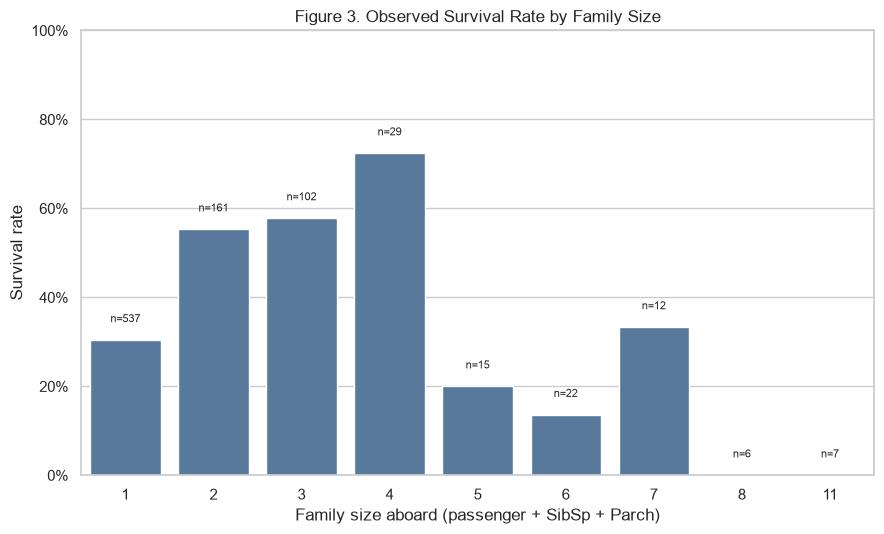

In [11]:
family_plot = family_summary.copy()
family_plot["family_label"] = family_plot["family_size"].astype(str)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=family_plot,
    x="family_label",
    y="survival_rate",
    color="#4C78A8",
    ax=ax,
)
ax.set_title("Figure 3. Observed Survival Rate by Family Size")
ax.set_xlabel("Family size aboard (passenger + SibSp + Parch)")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
for index, row in family_plot.reset_index(drop=True).iterrows():
    ax.text(
        index,
        min(row["survival_rate"] + 0.035, 0.97),
        f"n={int(row['passengers'])}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
fig.tight_layout()
fig.savefig(FIGURE_DIR / "figure_3_survival_by_family_size.png", dpi=180)
plt.show()

**Figure 3 interpretation.** Passengers in families of two to four had higher
observed survival than passengers traveling alone. Rates fall for larger families,
but the labels show that the largest family-size categories contain few passengers;
those unstable rates should not drive a general conclusion without uncertainty
analysis and additional context.

## 6. Summary and Interpretation

The workflow found an overall observed survival rate of 38.4%. Recorded sex and
passenger class show the clearest descriptive separation: female passengers had
higher survival rates in every class, and first-class passengers had higher rates
than third-class passengers. Family size also shows a non-linear pattern, with the
highest observed rate among families of four, while age distributions overlap.

The analysis assumes that the Kaggle training file faithfully represents the
underlying passenger records and that `SibSp` and `Parch` can be combined into a
useful household-size proxy. Group-median age imputation reduces row loss but can
compress within-group variation, and missingness may itself be informative. Cabin
was too incomplete for responsible category-level analysis, so the workflow keeps
only a missingness indicator.

Important limitations remain. The data are historical and observational, several
groups are small, and selection or recording processes may not be random. The
visualizations describe associations rather than causes. A future analysis should
add uncertainty intervals, test sensitivity to alternative age handling, document
dataset provenance in greater depth, and evaluate whether conclusions change when
imputed ages are excluded.

One surprising feature is that the median recorded age is similar for survivors and
non-survivors even though the distributions differ locally. This is a useful reminder
that a single summary statistic can conceal important structure and that plots should
be interpreted alongside data-quality information and group counts.